In [ ]:
# Step 1: Load the Data
# ● Load both CSVs into Pandas DataFrames
import pandas as pd
df1=pd.read_csv("/content/Customer_Master_Data.csv")
df2=pd.read_csv("/content/Customer_Transactions.csv")
df1.head()


,CustomerID,Name,Email,Gender,Age,City,MaritalStatus,NumChildren,JoinDate
0,CUST10000,Onkar Bhargava,pkeer@yahoo.com,Male,54,Delhi,Divorced,0,2021-02-22
1,CUST10001,Divit Kohli,mkalita@sarin.com,Female,48,Kolkata,Married,0,2023-12-06
2,CUST10002,Kiara Behl,apteanay@hotmail.com,Male,75,Kolkata,Widowed,2,2023-08-23
3,CUST10003,Vaibhav Sankar,bseshadri@choudhry.info,Male,62,Pune,Divorced,2,2022-11-17
4,CUST10004,Shray D’Alia,bdhillon@toor-mall.com,Male,55,Delhi,Divorced,0,2022-12-04


In [ ]:
# Check shape, structure, and preview
df2.head()

,CustomerID,TransactionDate,TransactionAmount
0,CUST10771,7/31/23,2383.07
1,CUST10100,3/10/24,497.54
2,CUST10031,2/17/25,536.78
3,CUST10987,7/17/23,314.89
4,CUST10831,12/15/24,2543.19


In [ ]:
"DF1 shape:", df1.shape


('DF1 shape:', (1000, 9))

In [ ]:
df2.shape

(23050, 3)

In [ ]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   CustomerID     1000 non-null   object
 1   Name           1000 non-null   object
 2   Email          1000 non-null   object
 3   Gender         1000 non-null   object
 4   Age            1000 non-null   int64 
 5   City           1000 non-null   object
 6   MaritalStatus  1000 non-null   object
 7   NumChildren    1000 non-null   int64 
 8   JoinDate       1000 non-null   object
dtypes: int64(2), object(7)
memory usage: 70.4+ KB


In [ ]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23050 entries, 0 to 23049
Data columns (total 3 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         23050 non-null  object 
 1   TransactionDate    23050 non-null  object 
 2   TransactionAmount  23050 non-null  float64
dtypes: float64(1), object(2)
memory usage: 540.4+ KB


In [ ]:
# Convert JoinDate and TransactionDate columns to datetime
df1["JoinDate"] = pd.to_datetime(df1["JoinDate"])


In [ ]:
df2["TransactionDate"] = pd.to_datetime(df2["TransactionDate"], errors="coerce")


/tmp/ipython-input-184349538.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df2["TransactionDate"] = pd.to_datetime(df2["TransactionDate"], errors="coerce")


In [ ]:
# Ensure no nulls or bad types
("Null JoinDate values:", df1["JoinDate"].isnull().sum())

('Null JoinDate values:', np.int64(0))

In [ ]:
("Null TransactionDate values:", df2["TransactionDate"].isnull().sum())

('Null TransactionDate values:', np.int64(0))

In [ ]:
df1=df1.dropna(subset=["CustomerID", "JoinDate"])

In [ ]:
df2=df2.dropna(subset=["CustomerID", "TransactionDate"])

In [ ]:
df1["CustomerID"] = df1["CustomerID"].astype(str)

In [ ]:
df2["CustomerID"] = df2["CustomerID"].astype(str)


In [ ]:
duplicate_customers = df1[df1.duplicated(subset="CustomerID", keep=False)]
print("Duplicate CustomerIDs in master:", duplicate_customers.shape[0])

Duplicate CustomerIDs in master: 0


In [ ]:
invalid_transactions = df2[~df2["CustomerID"].isin(df1["CustomerID"])]
("Transactions with invalid CustomerIDs:", invalid_transactions.shape[0])

('Transactions with invalid CustomerIDs:', 0)

In [ ]:
"Clean DF1 shape:", df1.shape


('Clean DF1 shape:', (1000, 9))

In [ ]:
("Clean DF2 shape:", df2.shape)

('Clean DF2 shape:', (23050, 3))

In [ ]:
# MERGE
# Join Customer_Master_Data with Customer_Transactions on CustomerID (if
# demographic data is required)



In [ ]:
merged_df = pd.merge(
    df2,
    df1,
    on="CustomerID",
    how="right",
)

In [ ]:
merged_df.head()

,CustomerID,TransactionDate,TransactionAmount,Name,Email,Gender,Age,City,MaritalStatus,NumChildren,JoinDate
0,CUST10000,2022-10-03,961.52,Onkar Bhargava,pkeer@yahoo.com,Male,54,Delhi,Divorced,0,2021-02-22
1,CUST10000,2024-05-31,92.16,Onkar Bhargava,pkeer@yahoo.com,Male,54,Delhi,Divorced,0,2021-02-22
2,CUST10000,2024-05-31,1153.74,Onkar Bhargava,pkeer@yahoo.com,Male,54,Delhi,Divorced,0,2021-02-22
3,CUST10000,2023-01-31,1217.04,Onkar Bhargava,pkeer@yahoo.com,Male,54,Delhi,Divorced,0,2021-02-22
4,CUST10000,2022-06-12,912.08,Onkar Bhargava,pkeer@yahoo.com,Male,54,Delhi,Divorced,0,2021-02-22


In [ ]:
# Perform RFM Calculation




In [ ]:
import pandas as pd

reference_date = merged_df["TransactionDate"].max() + pd.Timedelta(days=1)

df_rfm = (
    merged_df
    .groupby("CustomerID")
    .agg({
        "TransactionDate": [
            lambda x: (reference_date - x.max()).days,
            "count"
        ],
        "TransactionAmount": "sum"
    })
)

df_rfm.columns = ["Recency", "Frequency", "Monetary"]
df_rfm = df_rfm.reset_index()

print(df_rfm.head())


  CustomerID  Recency  Frequency  Monetary
0  CUST10000       13         23  21265.49
1  CUST10001       35         30  28654.31
2  CUST10002       18         24  23884.03
3  CUST10003       81         25  24206.03
4  CUST10004        8         19  25565.30


In [ ]:
df_rfm["R_Score"] = pd.qcut(df_rfm["Recency"], 5, labels=[5,4,3,2,1])

df_rfm["F_Score"] = pd.qcut(df_rfm["Frequency"].rank(method="first"), 5, labels=[1,2,3,4,5])
df_rfm["M_Score"] = pd.qcut(df_rfm["Monetary"].rank(method="first"), 5, labels=[1,2,3,4,5])

df_rfm[["R_Score", "F_Score", "M_Score"]] = df_rfm[["R_Score", "F_Score", "M_Score"]].astype(str)


In [ ]:
df_rfm["RFM_Segment"] = (
    df_rfm["R_Score"] +
    df_rfm["F_Score"] +
    df_rfm["M_Score"]
)

(df_rfm[["CustomerID", "RFM_Segment"]].head())


,CustomerID,RFM_Segment
0,CUST10000,432
1,CUST10001,355
2,CUST10002,433
3,CUST10003,143
4,CUST10004,514


In [ ]:
def rfm_label(row):
    r, f, m = int(row["R_Score"]), int(row["F_Score"]), int(row["M_Score"])

    if r >= 4 and f >= 4 and m >= 4:
        return "Champions"
    elif r >= 4 and f >= 3:
        return "Loyal Customers"
    elif r >= 4 and f <= 2:
        return "Potential Loyalist"
    elif r == 3 and f >= 3:
        return "Needs Attention"
    elif r <= 2 and f >= 3:
        return "At Risk"
    elif r <= 2 and m >= 4:
        return "Can't Lose"
    else:
        return "Hibernating"

df_rfm["Segment_Label"] = df_rfm.apply(rfm_label, axis=1)

df_rfm.head()


,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Segment,Segment_Label
0,CUST10000,13,23,21265.49,4,3,2,432,Loyal Customers
1,CUST10001,35,30,28654.31,3,5,5,355,Needs Attention
2,CUST10002,18,24,23884.03,4,3,3,433,Loyal Customers
3,CUST10003,81,25,24206.03,1,4,3,143,At Risk
4,CUST10004,8,19,25565.30,5,1,4,514,Potential Loyalist


In [ ]:
# Business-Rule-Based RFM Segmentation

In [ ]:
def assign_segment(row):
    r, f, m = int(row["R_Score"]), int(row["F_Score"]), int(row["M_Score"])

    if r >= 4 and f >= 4 and m >= 4:
        return "Champions"
    elif f >= 4 and r >= 2:
        return "Loyal Customers"
    elif r >= 4 and f in [2, 3]:
        return "Potential Loyalist"
    elif r <= 2 and f >= 3:
        return "At Risk"
    elif r == 1 and f <= 2 and m <= 2:
        return "Lost"
    elif m >= 4 and f in [2, 3] and r in [3, 4]:
        return "Big Spenders"
    else:
        return "Others"

df_rfm["Segment"] = df_rfm.apply(assign_segment, axis=1)


In [ ]:
df_rfm.head()

,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Segment,Segment_Label,Segment
0,CUST10000,13,23,21265.49,4,3,2,432,Loyal Customers,Potential Loyalist
1,CUST10001,35,30,28654.31,3,5,5,355,Needs Attention,Loyal Customers
2,CUST10002,18,24,23884.03,4,3,3,433,Loyal Customers,Potential Loyalist
3,CUST10003,81,25,24206.03,1,4,3,143,At Risk,At Risk
4,CUST10004,8,19,25565.30,5,1,4,514,Potential Loyalist,Others


In [ ]:
# Visualizations

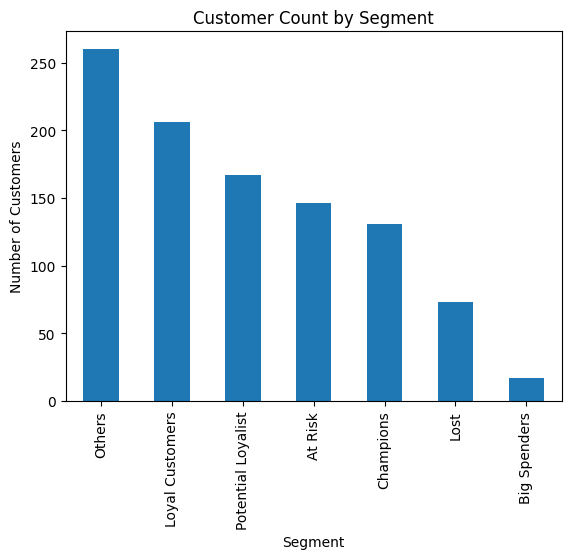

In [ ]:
import matplotlib.pyplot as plt

segment_counts = df_rfm["Segment"].value_counts()

plt.figure()
segment_counts.plot(kind="bar")
plt.title("Customer Count by Segment")
plt.xlabel("Segment")
plt.ylabel("Number of Customers")
plt.show()


In [ ]:
# Revenue Contribution per Segment

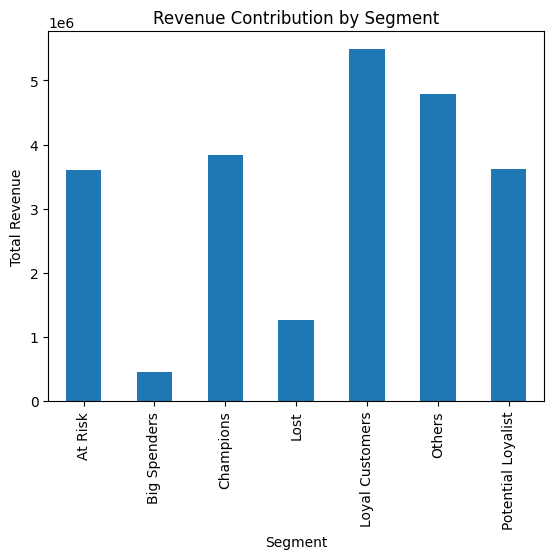

In [ ]:
segment_revenue = df_rfm.groupby("Segment")["Monetary"].sum()

plt.figure()
segment_revenue.plot(kind="bar")
plt.title("Revenue Contribution by Segment")
plt.xlabel("Segment")
plt.ylabel("Total Revenue")
plt.show()


In [ ]:
# Recency vs Monetary Scatter Plot (Colored by Segment)

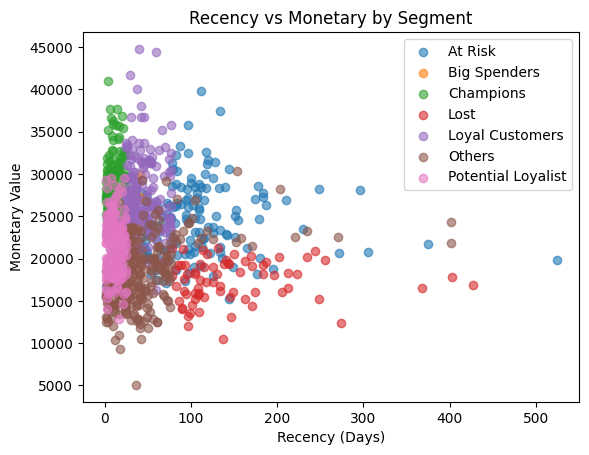

In [ ]:
plt.figure()

for segment, data in df_rfm.groupby("Segment"):
    plt.scatter(data["Recency"], data["Monetary"], label=segment, alpha=0.6)

plt.title("Recency vs Monetary by Segment")
plt.xlabel("Recency (Days)")
plt.ylabel("Monetary Value")
plt.legend()
plt.show()
